In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/raw/marketing_campaign.csv", sep="\t")

## Data Quality Assesment

In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [5]:

# 1. Compute missing count and percentage, then combine into a table
missing_table = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': ((df.isnull().sum() / len(df)) * 100).round(2)
}).rename_axis('Feature').reset_index()

# 2. View the table
print(missing_table)


                Feature  Missing Count  Percentage (%)
0                    ID              0            0.00
1            Year_Birth              0            0.00
2             Education              0            0.00
3        Marital_Status              0            0.00
4                Income             24            1.07
5               Kidhome              0            0.00
6              Teenhome              0            0.00
7           Dt_Customer              0            0.00
8               Recency              0            0.00
9              MntWines              0            0.00
10            MntFruits              0            0.00
11      MntMeatProducts              0            0.00
12      MntFishProducts              0            0.00
13     MntSweetProducts              0            0.00
14         MntGoldProds              0            0.00
15    NumDealsPurchases              0            0.00
16      NumWebPurchases              0            0.00
17  NumCat

In [6]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 0


In [8]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

## Customer Demographics

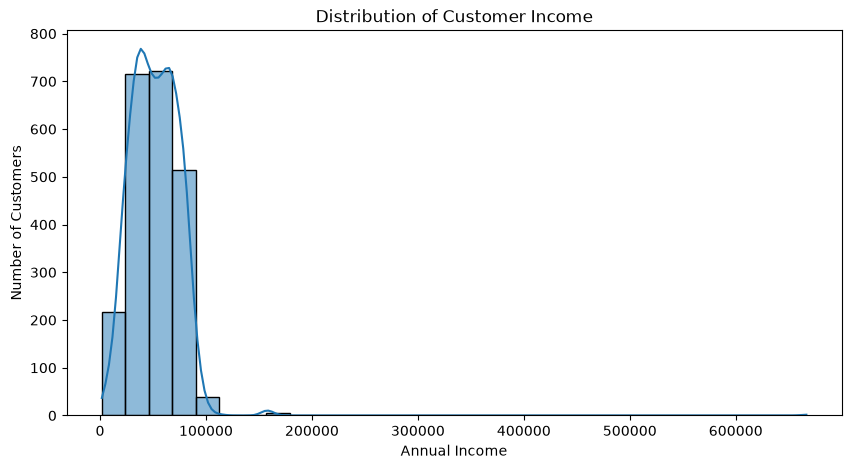

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Income",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

- Customer income follows a **positively skewed distribution**, with most customers concentrated in the low-to-middle income ranges.
- A relatively small proportion of customers belong to the high-income segment, indicating substantial variation in purchasing power across the customer base.
- The presence of a long right tail suggests that income may play an important role in differentiating customer groups during segmentation.

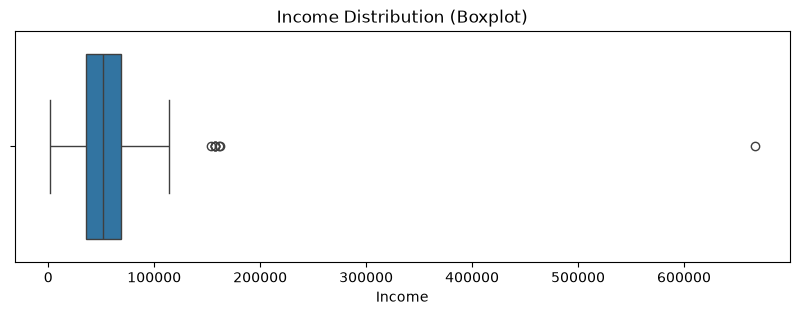

In [10]:
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df,
    x="Income"
)

plt.title("Income Distribution (Boxplot)")

plt.show()

### Interpretation

- The income distribution contains several high-income outliers, including one extreme observation that lies substantially outside the overall distribution.
- At this stage, these observations cannot be classified as errors because they may represent genuine high-income customers.
- The impact of these outliers will be evaluated during preprocessing before deciding whether they should be retained, transformed, or removed.

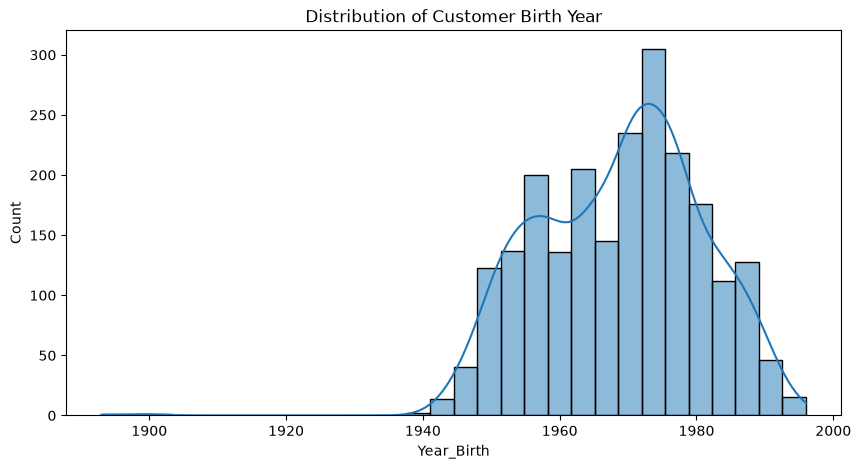

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Year_Birth",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Birth Year")

plt.show()

### Interpretation

- Most customers were born between the mid-1950s and late-1980s, indicating that the customer base is largely composed of mature adults.
- The distribution appears approximately bell-shaped, with the highest concentration around the early 1970s.
- A very small number of unusually early birth years are present and will be investigated further to determine whether they represent valid observations or data quality issues.

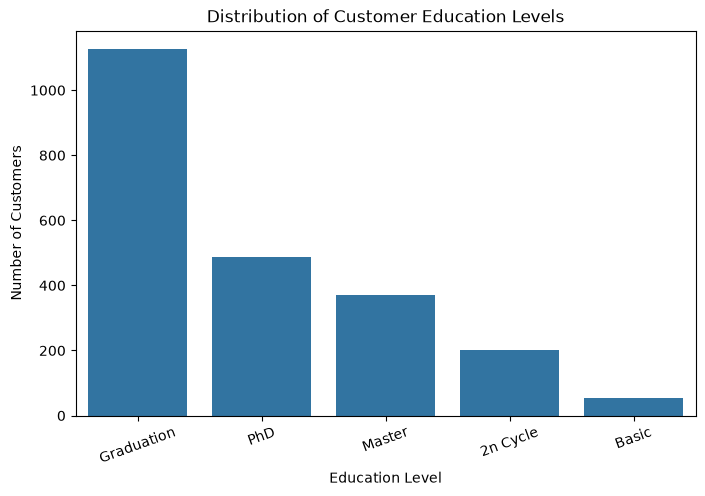

In [12]:
plt.figure(figsize=(8,5))

education_order = (
    df["Education"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    x="Education",
    order=education_order
)

plt.title("Distribution of Customer Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Interpretation

- More than half of the customers have a **Graduation** degree, followed by **PhD** and **Master's** qualifications.
- Customers with only **Basic** education represent a very small proportion of the dataset.
- The strong representation of higher education levels suggests that education may be a meaningful demographic feature when profiling customer segments and analyzing purchasing behaviour.

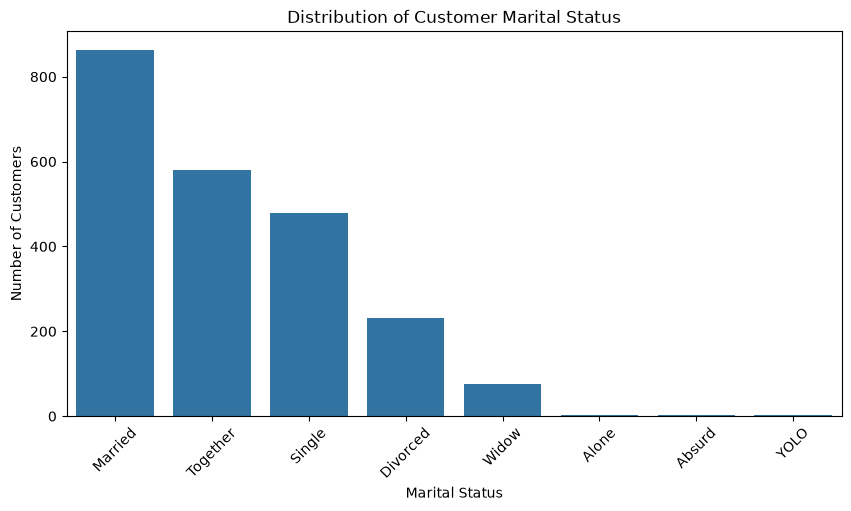

In [13]:
plt.figure(figsize=(10,5))

marital_order = (
    df["Marital_Status"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    x="Marital_Status",
    order=marital_order
)

plt.title("Distribution of Customer Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

### Interpretation

- **Married**, **Together**, and **Single** customers account for the majority of the customer base.
- Categories such as **Alone**, **Absurd**, and **YOLO** contain very few observations and are unlikely to represent meaningful customer groups.
- These rare categories will be evaluated during feature engineering and may be consolidated into broader marital status categories to improve analytical consistency.

## Customer Spending Behaviour

In [14]:
spending_categories = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

total_spending = df[spending_categories].sum().sort_values(ascending=False)

total_spending

MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64

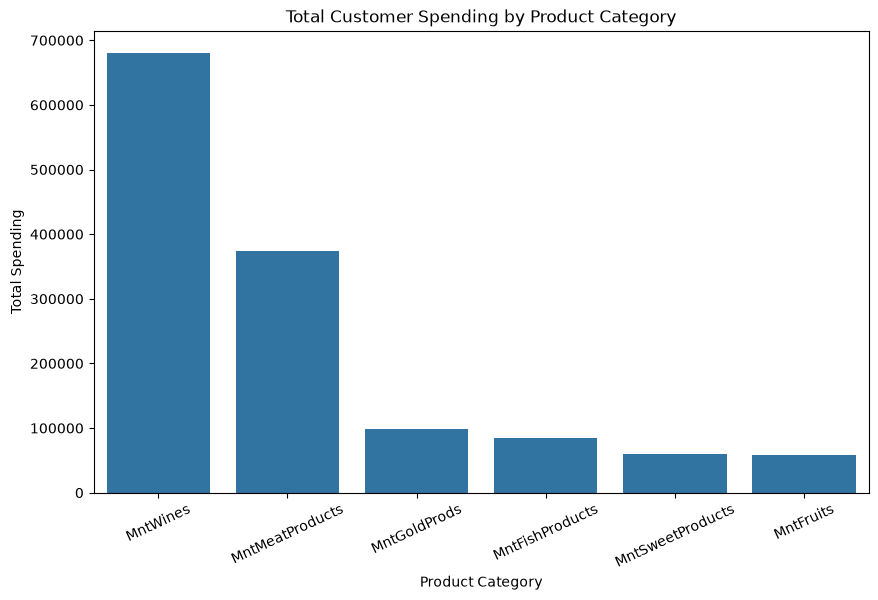

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=total_spending.index,
    y=total_spending.values
)

plt.title("Total Customer Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Spending")

plt.xticks(rotation=25)

plt.show()


### Interpretation

- Wine products contribute the highest share of total customer spending, followed by meat products.
- Spending on fruits, fish, sweets, and gold products is considerably lower in comparison.
- Customer spending is concentrated in a small number of product categories, indicating that product preferences are not evenly distributed across the retail portfolio.

In [16]:
average_spending = (
    df[spending_categories]
    .mean()
    .sort_values(ascending=False)
)

average_spending

MntWines            303.935714
MntMeatProducts     166.950000
MntGoldProds         44.021875
MntFishProducts      37.525446
MntSweetProducts     27.062946
MntFruits            26.302232
dtype: float64

In [18]:
purchase_channels = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

channel_usage = (
    df[purchase_channels]
    .sum()
    .sort_values(ascending=False)
)

channel_usage

NumStorePurchases      12970
NumWebPurchases         9150
NumCatalogPurchases     5963
dtype: int64

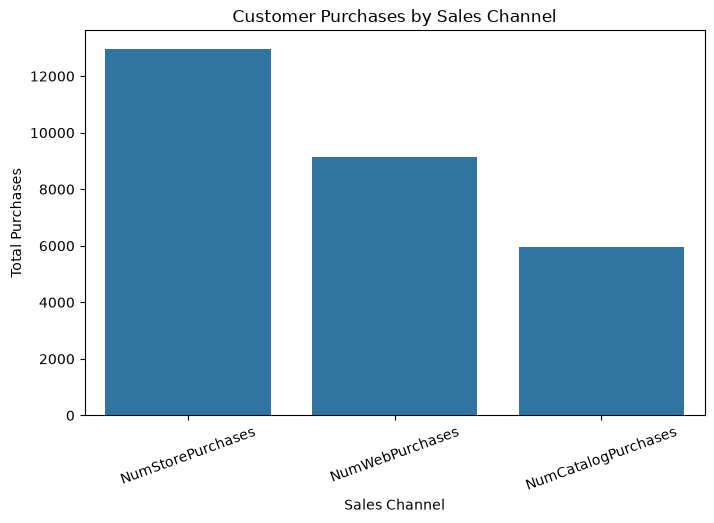

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=channel_usage.index,
    y=channel_usage.values
)

plt.title("Customer Purchases by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Purchases")

plt.xticks(rotation=20)

plt.show()

### Interpretation

- Customers predominantly purchase through the Store Purchase Channel, followed by the remaining channels.
- The distribution of purchases across these different channels provides insight into customer shopping preferences and may influence future channel-specific marketing strategies.
- Understanding this usage will also support customer profiling during the segmentation phase.

## Bivariate Analysis

In [ ]:
df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)


0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2240, dtype: int64

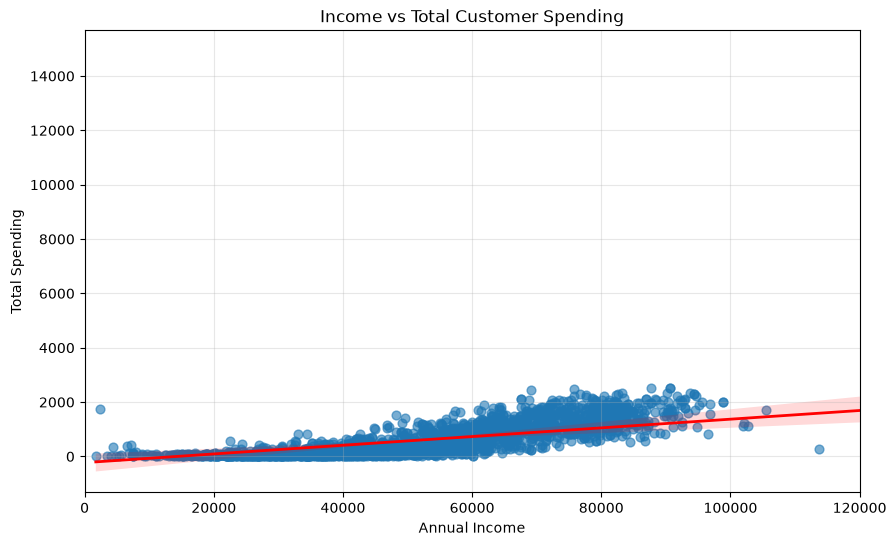

In [26]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="Income",
    y="Total_Spending",
    scatter_kws={"alpha":0.6, "s":40},
    line_kws={"color":"red", "linewidth":2}
)

plt.xlim(0, 120000)

plt.title("Income vs Total Customer Spending")
plt.xlabel("Annual Income")
plt.ylabel("Total Spending")

plt.grid(alpha=0.3)

plt.show()

In [27]:
correlation = df["Income"].corr(df["Total_Spending"])

print(f"Correlation: {correlation:.2f}")

Correlation: 0.67


### Interpretation

- Customer income and total spending exhibit a **moderately strong positive correlation (r = 0.67)**, indicating that customers with higher annual incomes generally spend more.
- Despite this positive trend, spending varies noticeably among customers with similar income levels, suggesting that purchasing behaviour is influenced by additional demographic and behavioural factors.
- A small number of extreme income observations were retained in the dataset but excluded from the visualization range to improve readability. These observations will be further evaluated during preprocessing.

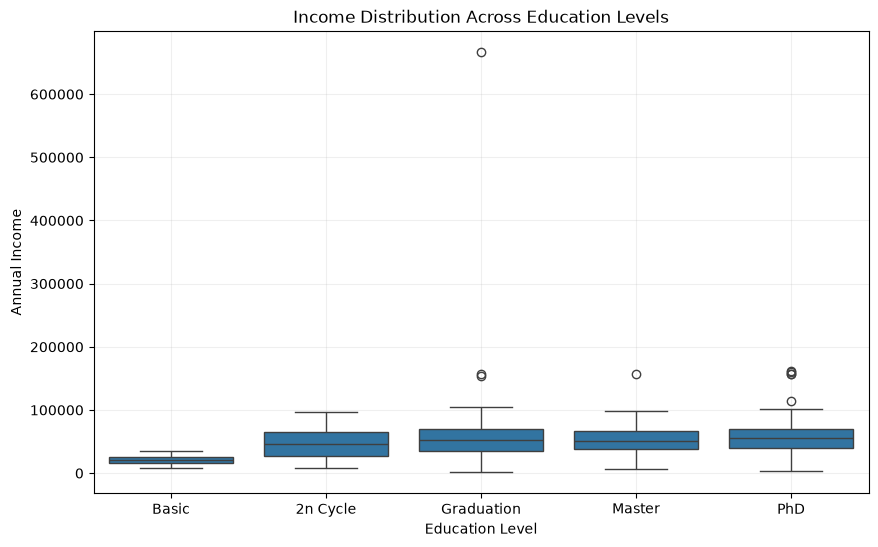

In [28]:
plt.figure(figsize=(10,6))

education_order = ["Basic", "2n Cycle", "Graduation", "Master", "PhD"]

sns.boxplot(
    data=df,
    x="Education",
    y="Income",
    order=education_order
)

plt.title("Income Distribution Across Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Annual Income")

plt.grid(alpha=0.2)

plt.show()

In [29]:
education_income = (
    df.groupby("Education")["Income"]
      .median()
      .sort_values(ascending=False)
)

education_income

Education
PhD           55212.0
Graduation    52028.5
Master        50943.0
2n Cycle      46805.0
Basic         20744.0
Name: Income, dtype: float64

### Interpretation

- Customers with higher educational qualifications generally exhibit higher median incomes, with **PhD holders reporting the highest median income (55,212)** and customers with **Basic education reporting the lowest (20,744)**.
- Income distributions for **Graduation**, **Master**, and **PhD** overlap considerably, indicating that education alone does not fully explain customer earning potential.
- A small number of high-income outliers are present across multiple education levels and will be reviewed during preprocessing.

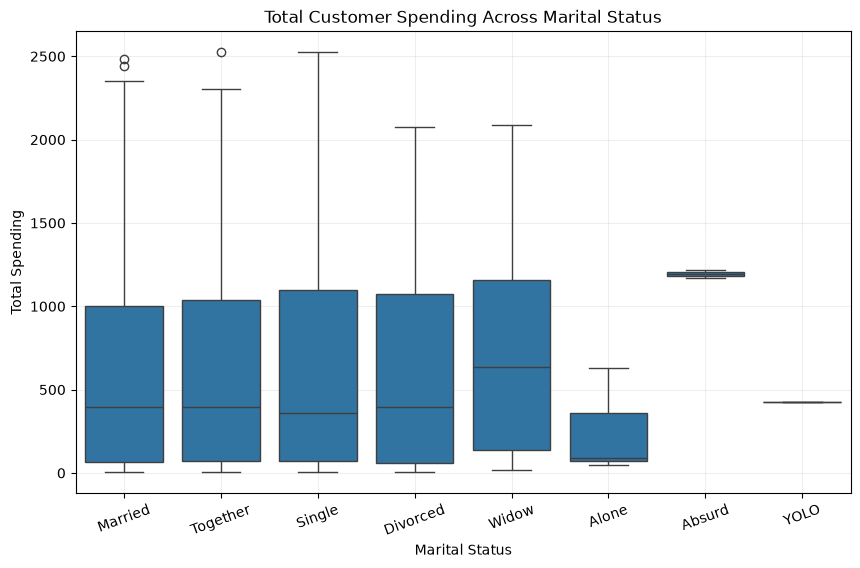

In [30]:
plt.figure(figsize=(10,6))

marital_order = [
    "Married",
    "Together",
    "Single",
    "Divorced",
    "Widow",
    "Alone",
    "Absurd",
    "YOLO"
]

sns.boxplot(
    data=df,
    x="Marital_Status",
    y="Total_Spending",
    order=marital_order
)

plt.title("Total Customer Spending Across Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Total Spending")

plt.xticks(rotation=20)

plt.grid(alpha=0.2)

plt.show()

In [31]:
marital_spending = (
    df.groupby("Marital_Status")["Total_Spending"]
      .median()
      .sort_values(ascending=False)
)

marital_spending

Marital_Status
Absurd      1192.5
Widow        636.0
YOLO         424.0
Married      396.5
Divorced     395.0
Together     393.5
Single       361.0
Alone         89.0
Name: Total_Spending, dtype: float64

### Interpretation

- Among the major customer groups, **Married**, **Together**, **Single**, and **Divorced** customers exhibit relatively similar spending distributions, suggesting that marital status alone is not a strong differentiating factor for customer spending.
- **Widow** customers display a higher median spending than the other major groups; however, this category represents a much smaller portion of the dataset and should be interpreted with caution.
- Categories such as **Absurd**, **YOLO**, and **Alone** contain very few observations, making their spending distributions unreliable for drawing meaningful business conclusions.
- The considerable overlap in spending distributions across most marital status groups indicates that behavioural variables are likely to be more informative than marital status for customer segmentation.

## Correlation Analysis

In [34]:
correlation_features = [
    "Income",
    "Recency",
    "Total_Spending",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "NumDealsPurchases",
    "Response"
]

corr_matrix = df[correlation_features].corr()

corr_matrix

,Income,Recency,Total_Spending,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,NumDealsPurchases,Response
Income,1.000000,-0.003970,0.667576,0.387878,0.589162,0.529362,-0.553088,-0.083101,0.133047
Recency,-0.003970,1.000000,0.020433,-0.010726,0.025110,0.000799,-0.021445,-0.001098,-0.198437
Total_Spending,0.667576,0.020433,1.000000,0.519837,0.778577,0.674669,-0.500218,-0.065112,0.265298
NumWebPurchases,0.387878,-0.010726,0.519837,1.000000,0.378376,0.502713,-0.055846,0.234185,0.148730
NumCatalogPurchases,0.589162,0.025110,0.778577,0.378376,1.000000,0.518738,-0.520364,-0.008617,0.220810
NumStorePurchases,0.529362,0.000799,0.674669,0.502713,0.518738,1.000000,-0.428473,0.068879,0.039363
NumWebVisitsMonth,-0.553088,-0.021445,-0.500218,-0.055846,-0.520364,-0.428473,1.000000,0.347633,-0.003987
NumDealsPurchases,-0.083101,-0.001098,-0.065112,0.234185,-0.008617,0.068879,0.347633,1.000000,0.002238
Response,0.133047,-0.198437,0.265298,0.148730,0.220810,0.039363,-0.003987,0.002238,1.000000


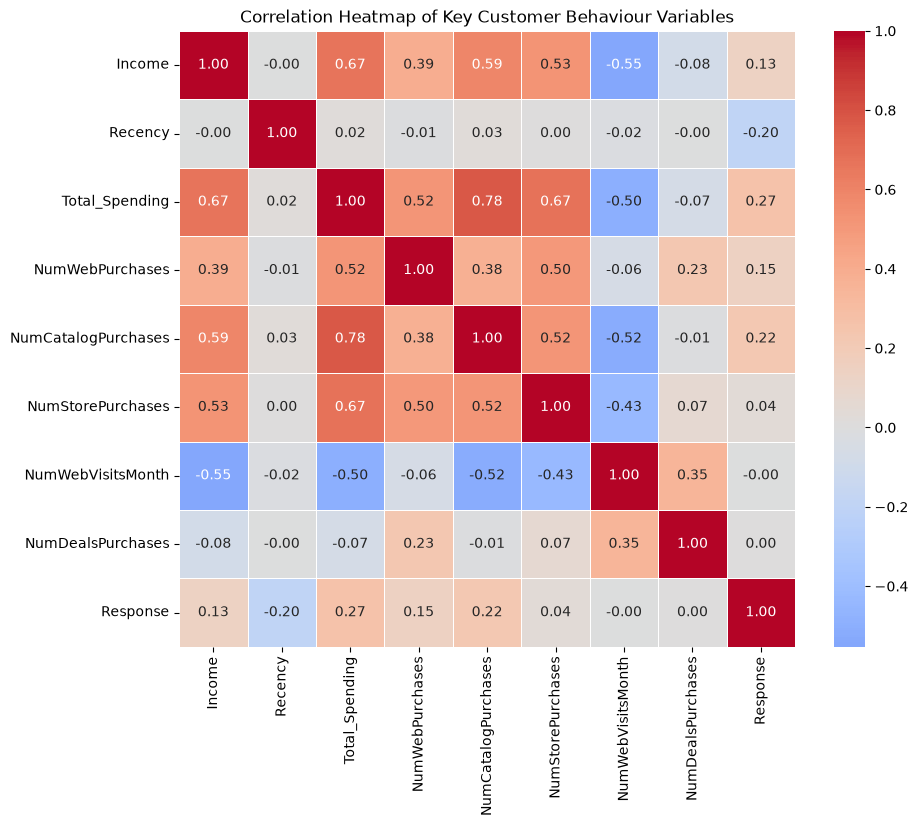

In [35]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Key Customer Behaviour Variables")

plt.show()

### Interpretation

- **Income** exhibits a moderately strong positive correlation with **Total Spending** (**r = 0.67**), reinforcing the earlier observation that customers with higher incomes generally spend more.
- **Total Spending** has the strongest positive relationship with **NumCatalogPurchases** (**r = 0.78**), followed by **NumStorePurchases** (**r = 0.67**) and **NumWebPurchases** (**r = 0.52**), indicating that purchase frequency across sales channels is closely associated with overall customer spending.
- **NumWebVisitsMonth** is moderately negatively correlated with **Income** (**r = -0.55**) and **Total Spending** (**r = -0.50**), suggesting that customers who visit the website more frequently do not necessarily make more purchases or spend more.
- **Response** demonstrates relatively weak correlations with the selected variables, indicating that campaign acceptance is likely influenced by additional customer characteristics beyond spending behaviour alone.
- Overall, the selected variables exhibit meaningful relationships without evidence of excessive multicollinearity, making them suitable for subsequent feature engineering and customer segmentation.